
<div style="display:flex; justify-content:space-between; align-items:flex-start;">
    <img src="./logo_UNSAM.jpg" width="130">
</div>

<div style="text-align:center; margin-top:80px;">

<h1 style="margin-bottom:10px;">Análisis y Procesamiento de Señales</h1>
    
<h2 style="margin-top:0; font-weight:normal;">
        Trabajo Práctico Nº 0
</h2>

<br><br>

<p style="font-size:18px;">
        Mora De La Corte
</p>

<p style="font-size:16px;">
        2026
</p>

</div>


## Introducción
Para la realización de este trabajo  se tomó como punto de partida el notebook *"notebook0.ipynb"*, provisto por la cátedra. 

Se realizaron diversas modificaciones, con el objetivo de familiarizarse con el entorno de trabajo, practicar el uso de las herramientas disponibles y comenzar a explorar los conceptos fundamentales que se abordarán a lo largo de la materia.

Los cambios efectuados se describen en detalle al final del presente informe.

## Inicialización del entorno

En esta sección se presenta la inicialización general del código y se detallan los módulos utilizados.

In [22]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on ...

@author: ...

Descripción:
------------
"""

# Importación de módulos 
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pdsmodulos as pds


## Definición de funciones

A continuación, se presentan las definiciones de las funciones utilizadas a lo largo de este notebook.

In [19]:
# Definicion de funciones
def my_testbench( sig_type ):
    
    # Datos generales de la simulación
    fs = 1000.0 # frecuencia de muestreo (Hz)
    N = 1000   # cantidad de muestras
    
    ts = 1/fs # tiempo de muestreo
    df = fs/N # resolución espectral
    
    # grilla de sampleo temporal
    tt = np.linspace(0, (N-1)*ts, N).flatten()
    
    # grilla de sampleo frecuencial
    ff = np.linspace(0, (N-1)*df, N).flatten()

    # Concatenación de matrices:
    x = np.array([], dtype=float).reshape(N,0)
    ii = 0
    
    # estructuras de control de flujo
    if sig_type['tipo'] == 'senoidal':
    
        
        # calculo cada senoidal de acuerdo a sus parámetros
        for this_freq in sig_type['frecuencia']:
            aux = sig_type['amplitud'][ii] * np.sin( 2*np.pi*this_freq*tt + sig_type['fase'][ii] )
            aux = aux + 0.1*np.random.randn(N) # Agrego ruido
            # para concatenar horizontalmente es necesario cuidar que tengan iguales FILAS
            x = np.hstack([x, aux.reshape(N,1)] )
            ii += 1
    
    elif sig_type['tipo'] == 'ruido':
        
        # calculo cada señal de ruido incorrelado (blanco), Gausiano de acuerdo a sus parámetros
        # de varianza
        for this_var in sig_type['varianza']:
            aux = np.sqrt(this_var) * np.random.randn(N,1)
            # para concatenar horizontalmente es necesario cuidar que tengan iguales FILAS
            x = np.hstack([x, aux] )
        sig_props['descripcion'] = [ sig_props['descripcion'][ii] + ' - $\\hat{{\\sigma}}^2$ :{0:.3f}'.format( np.var(x[:,ii]))  for ii in range(0,len(sig_props['descripcion'])) ]
    
    else:
        
        print("Tipo de señal no implementado.")        
        return
        
    #%% Presentación gráfica de los resultados
    
    plt.figure(figsize=(12,6)) # Defino el tamaño del grafico
    line_hdls = plt.plot(tt, x)
    plt.title('Señal: ' + sig_type['tipo'] )
    plt.xlabel('tiempo [segundos]')
    plt.ylabel('Amplitud [V]')
    plt.grid(which='both', axis='both')
    
    # presentar una leyenda para cada tipo de señal
    axes_hdl = plt.gca()
    axes_hdl.legend(line_hdls, sig_type['descripcion'], loc='upper right'  )
    
    plt.show()


## Implementación del codigo

En esta sección se muestran dos ejemplos de uso. 

El primero es para el caso senoidal y el segundo para una señal aleatoria *(Ruido blanco Gaussiano incorrelado de varianza $\sigma^2$)*

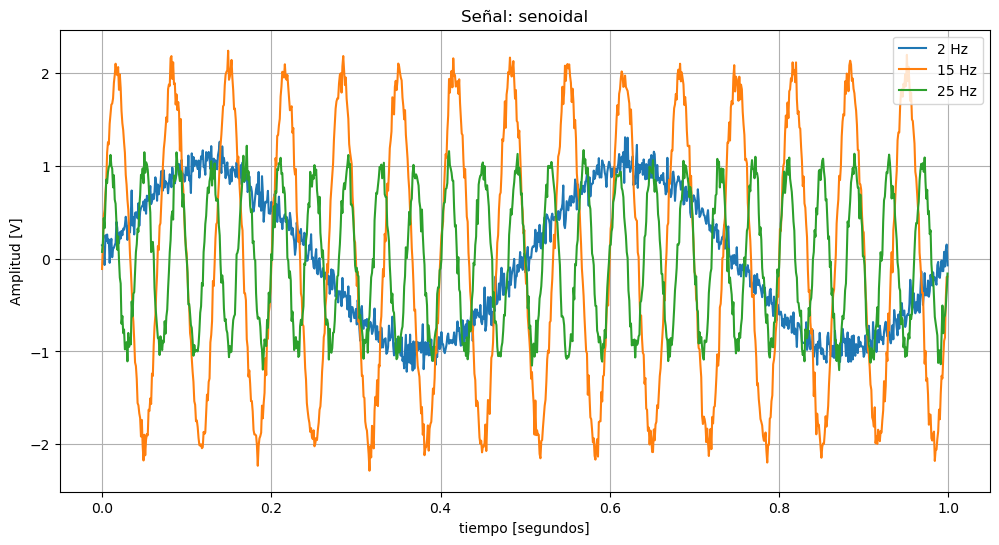

In [24]:
sig_props = { 'tipo': 'senoidal', 
              'frecuencia': (2, 15, 25), 
              'amplitud':   (1, 2,  1),
              'fase':       (0, 0,  0)
             } 

sig_props['descripcion'] = [ str(a_freq) + ' Hz' for a_freq in sig_props['frecuencia'] ]
    
my_testbench( sig_props )

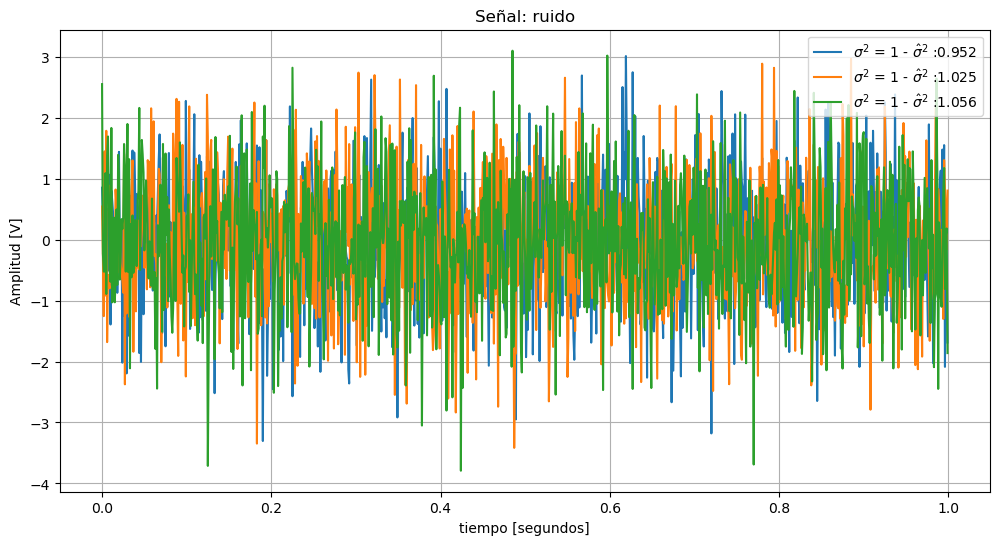

In [21]:
sig_props = { 'tipo': 'ruido', 
              'varianza': (1, 1, 1)
             } 
sig_props['descripcion'] = [ '$\sigma^2$ = ' + str(a_var) for a_var in sig_props['varianza'] ]
    
my_testbench( sig_props )


Como puede verse en la figura anterior, al samplear una distribución estadística de media nula y varianza $\sigma^2=1$, obtenemos realizaciones cuyo parámetro $\sigma^2$ estimado, es decir $\hat\sigma^2$, tienen una desviación respecto al verdadero valor (sesgo).

## Cambios realizados

Se realizaron modificaciones sobre el notebook original con el fin de experimentar con distintos parámetros de generación de señales y analizar cómo estos afectan su representación gráfica.

En particular, se agregó ruido a la señal senoidal y se modificaron los valores de ejemplo correspondientes a la frecuencia y amplitud. Además, se ajustó el tamaño de las figuras para mejorar la visualización de los resultados.

Por último, se reorganizó la estructura del documento, incorporando secciones explicativas y una portada personalizada. Estas modificaciones se realizaron con el objetivo de familiarizarse con el entorno de trabajo de Jupyter Notebook.